# Customer Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Step 1: Load the Data

● Load both CSVs into Pandas DataFrames

● Check shape, structure, and preview

In [2]:
cust = pd.read_csv(r"D:\Work\Career 247\Python\mini_project\Customer_Master_Data.csv")
tran = pd.read_csv(r"D:\Work\Career 247\Python\mini_project\Customer_Transactions.csv")

In [3]:
cust.head()

,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
1,CUST10001,Divit Kohli,mkalita@sarin.com,Female,48,Kolkata,Married,0,2023-12-06
2,CUST10002,Kiara Behl,apteanay@hotmail.com,Male,75,Kolkata,Widowed,2,2023-08-23
3,CUST10003,Vaibhav Sankar,bseshadri@choudhry.info,Male,62,Pune,Divorced,2,2022-11-17
4,CUST10004,Shray D’Alia,bdhillon@toor-mall.com,Male,55,Delhi,Divorced,0,2022-12-04


In [4]:
tran.head()

,CustomerID,TransactionDate,TransactionAmount
0,CUST10771,7/31/23,2383.07
1,CUST10100,3/10/24,497.54
2,CUST10031,2/17/25,536.78
3,CUST10987,7/17/23,314.89
4,CUST10831,12/15/24,2543.19


In [5]:
print(cust.info())
print(tran.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1000 non-null   object
 1   Name           1000 non-null   object
 2   Email          1000 non-null   object
 3   Gender         1000 non-null   object
 4   Age            1000 non-null   int64 
 5   City           1000 non-null   object
 6   MaritalStatus  1000 non-null   object
 7   NumChildren    1000 non-null   int64 
 8   JoinDate       1000 non-null   object
dtypes: int64(2), object(7)
memory usage: 70.4+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23050 entries, 0 to 23049
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         23050 non-null  object 
 1   TransactionDate    23050 non-null  object 
 2   TransactionAmount  23050 non-null  float64
dtypes: float64(1)

### Step 2: Clean the Data

● Convert JoinDate and TransactionDate columns to datetime

In [6]:
tran['TransactionDate'] = pd.to_datetime(tran['TransactionDate'])
cust['JoinDate'] = pd.to_datetime(cust['JoinDate'])

C:\Users\ANKIT\AppData\Local\Temp\ipykernel_34544\327917176.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tran['TransactionDate'] = pd.to_datetime(tran['TransactionDate'])


● Ensure no nulls or bad types

In [11]:
cust.isnull().sum()

CustomerID       0
Name             0
Email            0
Gender           0
Age              0
City             0
MaritalStatus    0
NumChildren      0
JoinDate         0
dtype: int64

In [13]:
tran.isnull().sum()

CustomerID           0
TransactionDate      0
TransactionAmount    0
dtype: int64

● Validate uniqueness of CustomerID in master dataset

In [17]:
cust['CustomerID'].unique()

array(['CUST10000', 'CUST10001', 'CUST10002', 'CUST10003', 'CUST10004',
       'CUST10005', 'CUST10006', 'CUST10007', 'CUST10008', 'CUST10009',
       'CUST10010', 'CUST10011', 'CUST10012', 'CUST10013', 'CUST10014',
       'CUST10015', 'CUST10016', 'CUST10017', 'CUST10018', 'CUST10019',
       'CUST10020', 'CUST10021', 'CUST10022', 'CUST10023', 'CUST10024',
       'CUST10025', 'CUST10026', 'CUST10027', 'CUST10028', 'CUST10029',
       'CUST10030', 'CUST10031', 'CUST10032', 'CUST10033', 'CUST10034',
       'CUST10035', 'CUST10036', 'CUST10037', 'CUST10038', 'CUST10039',
       'CUST10040', 'CUST10041', 'CUST10042', 'CUST10043', 'CUST10044',
       'CUST10045', 'CUST10046', 'CUST10047', 'CUST10048', 'CUST10049',
       'CUST10050', 'CUST10051', 'CUST10052', 'CUST10053', 'CUST10054',
       'CUST10055', 'CUST10056', 'CUST10057', 'CUST10058', 'CUST10059',
       'CUST10060', 'CUST10061', 'CUST10062', 'CUST10063', 'CUST10064',
       'CUST10065', 'CUST10066', 'CUST10067', 'CUST10068', 'CUST

● Ensure all transaction CustomerIDs exist in master data

In [18]:
tran['CustomerID'].isin(cust['CustomerID']).value_counts()

CustomerID
True    23050
Name: count, dtype: int64

### Step 3: Merge if Needed

● Join Customer_Master_Data with Customer_Transactions on CustomerID (if
demographic data is required)

In [19]:
df = pd.merge(tran,cust, on="CustomerID", how="left")

In [20]:
df.head()

,CustomerID,TransactionDate,TransactionAmount,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10771,2023-07-31,2383.07,Lakshay Dhillon,dharmajantara@gmail.com,Female,27,Ahmedabad,Widowed,3,2023-05-31
1,CUST10100,2024-03-10,497.54,Aniruddh Borah,jivikabhavsar@gmail.com,Female,53,Lucknow,Divorced,4,2022-01-08
2,CUST10031,2025-02-17,536.78,Ritvik Ahuja,jhaverifarhan@chandra.org,Male,40,Ahmedabad,Single,0,2023-12-03
3,CUST10987,2023-07-17,314.89,Jayan Wagle,ojas82@gmail.com,Not Disclosed,75,Bangalore,Widowed,4,2022-03-18
4,CUST10831,2024-12-15,2543.19,Ishita Agarwal,vbalay@yahoo.com,Not Disclosed,27,Jaipur,Divorced,4,2021-06-30


### Step 4: Perform RFM Calculation

● Use groupby on CustomerID for:

        o max(TransactionDate) → Recency
        o count(TransactionDate) → Frequency
        o count(TransactionDate) → Frequency

● Use a reference date to compute Recency in number of days

In [21]:
df['LastTransaction'] = df.groupby('CustomerID')['TransactionDate'].max()

In [22]:
LastDate = df.groupby('CustomerID')['TransactionDate'].max()
LastDate

CustomerID
CUST10000   2025-07-17
CUST10001   2025-06-25
CUST10002   2025-07-12
CUST10003   2025-05-10
CUST10004   2025-07-22
               ...    
CUST10995   2024-06-23
CUST10996   2025-07-15
CUST10997   2025-06-28
CUST10998   2025-03-26
CUST10999   2025-07-25
Name: TransactionDate, Length: 1000, dtype: datetime64[ns]

In [23]:
LastDate = df.groupby('CustomerID')['TransactionDate'].max().reset_index().rename(columns= {'TransactionDate': 'LastTreasactionDate'})
LastDate.head()

,CustomerID,LastTreasactionDate
0,CUST10000,2025-07-17
1,CUST10001,2025-06-25
2,CUST10002,2025-07-12
3,CUST10003,2025-05-10
4,CUST10004,2025-07-22


In [24]:
from datetime import timedelta
today = df['TransactionDate'].max()+timedelta(days=1)
today

Timestamp('2025-07-30 00:00:00')

In [25]:
cust['Recency']=(today-LastDate['LastTreasactionDate']).dt.days

In [26]:
cust.head()

,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate,Recency
0,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,13
1,CUST10001,Divit Kohli,mkalita@sarin.com,Female,48,Kolkata,Married,0,2023-12-06,35
2,CUST10002,Kiara Behl,apteanay@hotmail.com,Male,75,Kolkata,Widowed,2,2023-08-23,18
3,CUST10003,Vaibhav Sankar,bseshadri@choudhry.info,Male,62,Pune,Divorced,2,2022-11-17,81
4,CUST10004,Shray D’Alia,bdhillon@toor-mall.com,Male,55,Delhi,Divorced,0,2022-12-04,8


In [28]:
Frequency = df.groupby('CustomerID')['TransactionDate'].count().reset_index().rename(columns = {'TransactionDate':'Frequency'})
Frequency.head()

,CustomerID,Frequency
0,CUST10000,23
1,CUST10001,30
2,CUST10002,24
3,CUST10003,25
4,CUST10004,19


In [29]:
Monetary = df.groupby('CustomerID')['TransactionAmount'].sum().reset_index().rename(columns = {'TransactionAmount':'Monetary'})
Monetary.head()

,CustomerID,Monetary
0,CUST10000,21265.49
1,CUST10001,28654.31
2,CUST10002,23884.03
3,CUST10003,24206.03
4,CUST10004,25565.30


In [30]:
df.head()

,CustomerID,TransactionDate,TransactionAmount,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate,LastTransaction
0,CUST10771,2023-07-31,2383.07,Lakshay Dhillon,dharmajantara@gmail.com,Female,27,Ahmedabad,Widowed,3,2023-05-31,NaT
1,CUST10100,2024-03-10,497.54,Aniruddh Borah,jivikabhavsar@gmail.com,Female,53,Lucknow,Divorced,4,2022-01-08,NaT
2,CUST10031,2025-02-17,536.78,Ritvik Ahuja,jhaverifarhan@chandra.org,Male,40,Ahmedabad,Single,0,2023-12-03,NaT
3,CUST10987,2023-07-17,314.89,Jayan Wagle,ojas82@gmail.com,Not Disclosed,75,Bangalore,Widowed,4,2022-03-18,NaT
4,CUST10831,2024-12-15,2543.19,Ishita Agarwal,vbalay@yahoo.com,Not Disclosed,27,Jaipur,Divorced,4,2021-06-30,NaT


● Store result in a new DataFrame called df_rfm

In [32]:
df_rfm = pd.merge(cust[['CustomerID','Recency']], Frequency, on='CustomerID', how='left')

In [33]:
df_rfm = pd.merge(df_rfm, Monetary, on='CustomerID', how='left')

In [35]:
df_rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,CUST10000,13,23,21265.49
1,CUST10001,35,30,28654.31
2,CUST10002,18,24,23884.03
3,CUST10003,81,25,24206.03
4,CUST10004,8,19,25565.30


### Step 5: Score RFM

    ● Use quantile-based scoring using pd.qcut() or rank() and cut()
    ● Create three new columns: R_Score, F_Score, M_Score

In [36]:
df_rfm['R_score'] = pd.qcut(df_rfm['Recency'], 5, labels = [5,4,3,2,1])
df_rfm['F_score'] = pd.qcut(df_rfm['Frequency'], 5, labels = [1,2,3,4,5])
df_rfm['M_score'] = pd.qcut(df_rfm['Monetary'], 5, labels = [1,2,3,4,5])

In [37]:
df_rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score
0,CUST10000,13,23,21265.49,4,3,2
1,CUST10001,35,30,28654.31,3,5,5
2,CUST10002,18,24,23884.03,4,3,3
3,CUST10003,81,25,24206.03,1,4,3
4,CUST10004,8,19,25565.30,5,1,4


### Step 6: Create Combined RFM Segment

● Concatenate the R, F, M scores into a string like "555", "432", etc.

In [40]:
df_rfm['segment'] = df_rfm['R_score'].astype(str)+df_rfm['F_score'].astype(str)+df_rfm['M_score'].astype(str)

In [39]:
df_rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,segment
0,CUST10000,13,23,21265.49,4,3,2,432
1,CUST10001,35,30,28654.31,3,5,5,355
2,CUST10002,18,24,23884.03,4,3,3,433
3,CUST10003,81,25,24206.03,1,4,3,143
4,CUST10004,8,19,25565.30,5,1,4,514


### Step 7: Assign Segment Labels

    ● Use business rules to define segment labels for selected score combinations
          ● Example:
                 o RFM 555 → Champion
                 o RFM 111 → Lost
          (Refer RFM explanation above)

In [41]:
df_rfm['segment_Labels'] = 'others'

df_rfm.loc[df_rfm['segment'] == '555', 'segment_Labels'] = 'Champions'
df_rfm.loc[df_rfm['segment'] == '111', 'segment_Labels'] = 'Lost'
df_rfm.loc[df_rfm['segment'].str[0] == '5', 'segment_Labels'] = 'Recent'
df_rfm.loc[df_rfm['segment'].str[1] == '5', 'segment_Labels'] = 'Frequent'
df_rfm.loc[df_rfm['segment'].str[2] == '5', 'segment_Labels'] = 'Big Spenders'

In [44]:
df_rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,segment,segment_Labels
0,CUST10000,13,23,21265.49,4,3,2,432,others
1,CUST10001,35,30,28654.31,3,5,5,355,Big Spenders
2,CUST10002,18,24,23884.03,4,3,3,433,others
3,CUST10003,81,25,24206.03,1,4,3,143,others
4,CUST10004,8,19,25565.30,5,1,4,514,Recent


In [45]:
df_rfm['segment_Labels'].value_counts()

segment_Labels
others          543
Big Spenders    165
Recent          160
Frequent         63
Champions        35
Lost             34
Name: count, dtype: int64

## Step 8: Visualize

### ● Count of customers in each segment

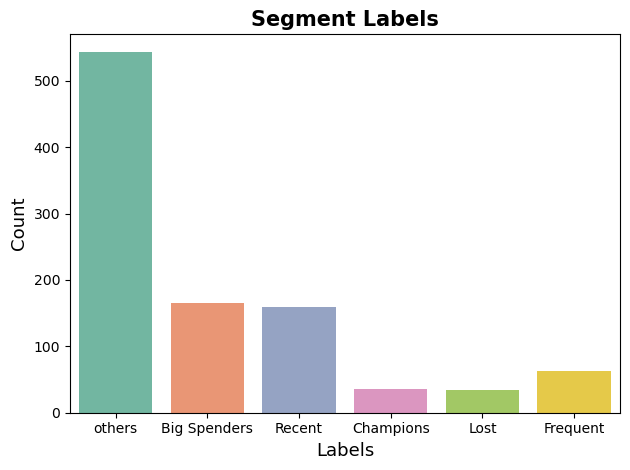

In [69]:
ax = sns.countplot(x='segment_Labels', data=df_rfm, hue='segment_Labels', palette='Set2', legend=False)

plt.title('Segment Labels', fontsize=15, fontweight='bold')
plt.xlabel('Labels', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.tight_layout()
plt.show()

### ● Revenue contribution per segment

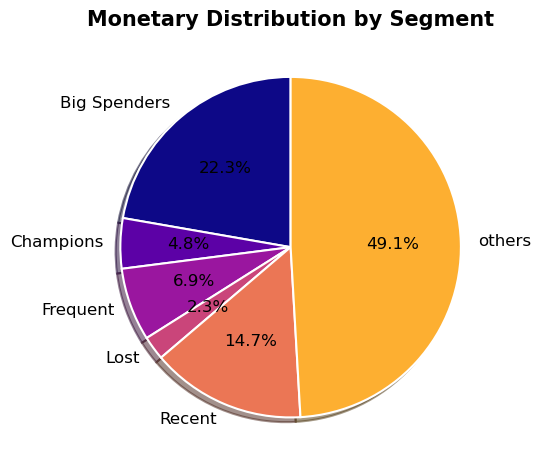

In [67]:
df_rfm.groupby('segment_Labels')['Monetary'].sum().plot(
    kind='pie',
    autopct='%0.1f%%',
    colors=plt.cm.plasma.colors[::len(plt.cm.plasma.colors) // df_rfm['segment_Labels'].nunique()],
    startangle=90,
    shadow=True,
    textprops={'fontsize': 12},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

plt.title('Monetary Distribution by Segment', fontsize=15, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

### ● Recency vs Monetary scatter plot colored by segment

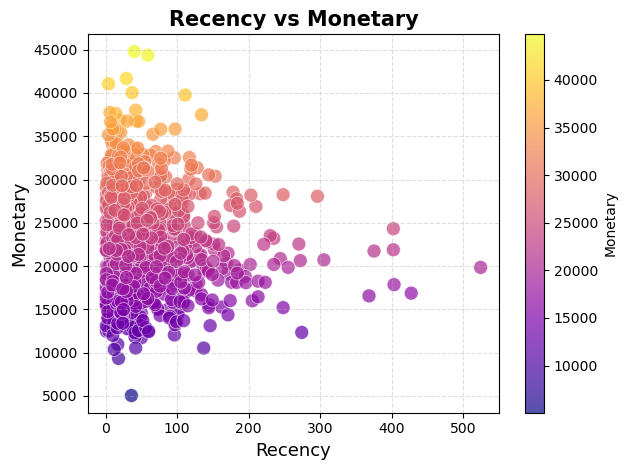

In [68]:
scatter = plt.scatter(
    df_rfm['Recency'], 
    df_rfm['Monetary'],
    c=df_rfm['Monetary'],
    cmap='plasma',
    s=100,
    alpha=0.7,
    edgecolors='white',
    linewidths=0.5
)

plt.colorbar(scatter, label='Monetary')
plt.xlabel('Recency', fontsize=13)
plt.ylabel('Monetary', fontsize=13)
plt.title('Recency vs Monetary', fontsize=15, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### ● Pareto Analysis: Show how top 20% customers contribute to 80% revenue

In [51]:
df_rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,segment,segment_Labels
0,CUST10000,13,23,21265.49,4,3,2,432,others
1,CUST10001,35,30,28654.31,3,5,5,355,Big Spenders
2,CUST10002,18,24,23884.03,4,3,3,433,others
3,CUST10003,81,25,24206.03,1,4,3,143,others
4,CUST10004,8,19,25565.30,5,1,4,514,Recent


In [53]:
df = df_rfm[['CustomerID', 'Monetary']]
df.head()

,CustomerID,Monetary
0,CUST10000,21265.49
1,CUST10001,28654.31
2,CUST10002,23884.03
3,CUST10003,24206.03
4,CUST10004,25565.30


In [54]:
df.sort_values(by= 'Monetary', ascending=False).head()

,CustomerID,Monetary
944,CUST10944,44784.99
510,CUST10510,44367.33
53,CUST10053,41674.56
776,CUST10776,41050.76
696,CUST10696,40035.48


In [84]:
df['Cumulative_Revenue'] = df['Monetary'].cumsum().copy()

In [56]:
df.head()

,CustomerID,Monetary,Cumulative_Revenue
0,CUST10000,21265.49,21265.49
1,CUST10001,28654.31,49919.80
2,CUST10002,23884.03,73803.83
3,CUST10003,24206.03,98009.86
4,CUST10004,25565.30,123575.16


In [85]:
df['Revenue_Percent'] = df['Cumulative_Revenue']/df['Monetary'].sum()*100

In [58]:
df = df.reset_index(drop=True)
df.head()

,CustomerID,Monetary,Cumulative_Revenue,Revenue_Percent
0,CUST10000,21265.49,21265.49,0.092245
1,CUST10001,28654.31,49919.80,0.216542
2,CUST10002,23884.03,73803.83,0.320146
3,CUST10003,24206.03,98009.86,0.425146
4,CUST10004,25565.30,123575.16,0.536043


In [59]:
df['Customer_Percent'] = (df.index+1)/len(df)*100

In [62]:
df[df['Customer_Percent']<=20].head()

,CustomerID,Monetary,Cumulative_Revenue,Revenue_Percent,Customer_Percent
0,CUST10000,21265.49,21265.49,0.092245,0.1
1,CUST10001,28654.31,49919.80,0.216542,0.2
2,CUST10002,23884.03,73803.83,0.320146,0.3
3,CUST10003,24206.03,98009.86,0.425146,0.4
4,CUST10004,25565.30,123575.16,0.536043,0.5


In [61]:
df[df['Customer_Percent']<=20].tail(5)

,CustomerID,Monetary,Cumulative_Revenue,Revenue_Percent,Customer_Percent
195,CUST10195,28863.54,4616262.31,20.024389,19.6
196,CUST10196,37738.94,4654001.25,20.188092,19.7
197,CUST10197,26897.07,4680898.32,20.304766,19.8
198,CUST10198,10974.66,4691872.98,20.352372,19.9
199,CUST10199,28694.82,4720567.80,20.476844,20.0


### Visualize

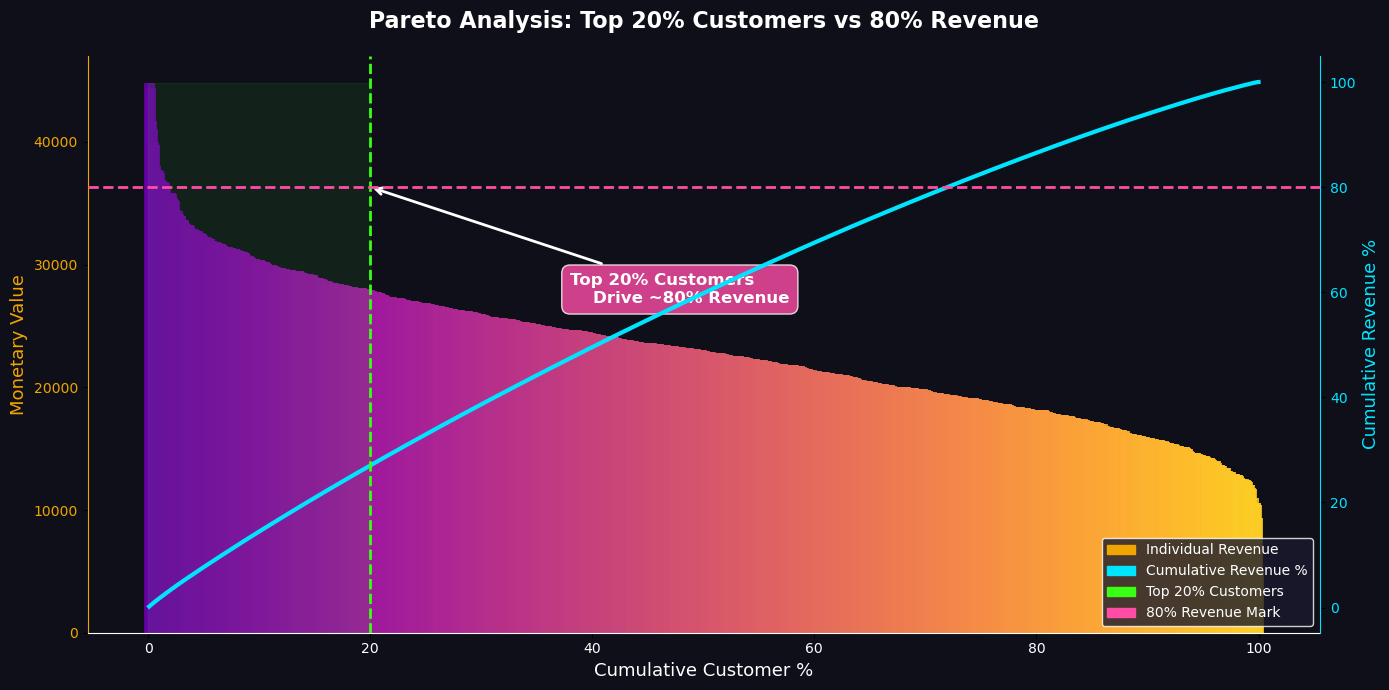

In [81]:
## Sorry but i take help of ClaudeAi to write this code.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

customer_monetary = df_rfm[['Monetary']].sort_values('Monetary', ascending=False).reset_index()

customer_monetary['cumulative_revenue'] = customer_monetary['Monetary'].cumsum()
customer_monetary['cumulative_revenue_pct'] = (customer_monetary['cumulative_revenue'] / customer_monetary['Monetary'].sum()) * 100
customer_monetary['cumulative_customer_pct'] = (np.arange(1, len(customer_monetary) + 1) / len(customer_monetary)) * 100

fig, ax1 = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#0f0f1a')
ax1.set_facecolor('#0f0f1a')

colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(customer_monetary)))
ax1.bar(
    customer_monetary['cumulative_customer_pct'],
    customer_monetary['Monetary'],
    color=colors,
    alpha=0.85,
    width=1.0
)

ax1.set_xlabel('Cumulative Customer %', fontsize=13, color='white')
ax1.set_ylabel('Monetary Value', fontsize=13, color='#f0a500')
ax1.tick_params(axis='y', labelcolor='#f0a500')
ax1.tick_params(axis='x', labelcolor='white')
ax1.spines['bottom'].set_color('white')
ax1.spines['left'].set_color('#f0a500')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2 = ax1.twinx()
ax2.set_facecolor('#0f0f1a')
ax2.plot(
    customer_monetary['cumulative_customer_pct'],
    customer_monetary['cumulative_revenue_pct'],
    color='#00e5ff',
    linewidth=3,
    zorder=5
)
ax2.set_ylabel('Cumulative Revenue %', fontsize=13, color='#00e5ff')
ax2.tick_params(axis='y', labelcolor='#00e5ff')
ax2.spines['right'].set_color('#00e5ff')
ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_visible(False)

ax2.axvline(x=20, color='#39ff14', linestyle='--', linewidth=2, zorder=6)
ax2.axhline(y=80, color='#ff4da6', linestyle='--', linewidth=2, zorder=6)

ax2.annotate(
    'Top 20% Customers\n    Drive ~80% Revenue',
    xy=(20, 80),
    xytext=(38, 58),
    fontsize=12,
    color='white',
    fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#ff4da6', alpha=0.8, edgecolor='white'),
    arrowprops=dict(arrowstyle='->', color='white', lw=2)
)

y_max = customer_monetary['Monetary'].max()
ax1.fill_betweenx(
    [0, y_max],
    0, 20,
    alpha=0.08,
    color='#39ff14'
)

bar_patch = mpatches.Patch(color='#f0a500', label='Individual Revenue')
line_patch = mpatches.Patch(color='#00e5ff', label='Cumulative Revenue %')
vline_patch = mpatches.Patch(color='#39ff14', label='Top 20% Customers')
hline_patch = mpatches.Patch(color='#ff4da6', label='80% Revenue Mark')

ax1.legend(
    handles=[bar_patch, line_patch, vline_patch, hline_patch],
    loc='lower right',
    fontsize=10,
    facecolor='#1a1a2e',
    edgecolor='white',
    labelcolor='white'
)

plt.title('Pareto Analysis: Top 20% Customers vs 80% Revenue',
          fontsize=16, fontweight='bold', color='white', pad=20)
plt.tight_layout()
plt.show()

